# Introduction to Machine Learning and Neural Networks

Author: Dr. Julie Butler

Date Created: June 1, 2026

Last Modified: June 4, 2026

## Introduction

## A Demonstration

## Coding a Neural Network with Python and Scikit-Learn

### Library Imports

In [1]:
#############
## IMPORTS ##
#############
# KaggleHub allows us to easily access datasets from Kaggle
import kagglehub
# Pandas allows us to read in and manipulate data
import pandas as pd
# MLPClassifier will be our neural network model, from the library scikit-learn
from sklearn.neural_network import MLPClassifier
# accuracy_score will allow us to evaluate our model's performance
from sklearn.metrics import accuracy_score
# ConfusionMatrixDisplay will allow us to visualize our model's performance
from sklearn.metrics import ConfusionMatrixDisplay
# train_test_split will allow us to split our data into training and testing sets
from sklearn.model_selection import train_test_split
# LabelEncoder will allow us to convert categorical variables into numerical variables
from sklearn.preprocessing import LabelEncoder
# StandardScaler will allow us to standardize our data
from sklearn.preprocessing import StandardScaler
# Seaborn will allow us to visualize our data
import seaborn as sns

/Users/juliebutler/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/juliebutler/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Import and Clean the Data Set

In [2]:
###################
## LOAD THE DATA ##
####################

# Download the Titanic dataset from Kaggle and get the address on the computer here the file is stored
path = kagglehub.dataset_download("yasserh/titanic-dataset")
print(path)

# Import the dataset using pandas and take a look at the first few rows
titanic_data = pd.read_csv(path + "/Titanic-Dataset.csv")
titanic_data.head()

/Users/juliebutler/.cache/kagglehub/datasets/yasserh/titanic-dataset/versions/1


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
# Take a look at the last few rows of the dataset as well
titanic_data.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [4]:
# Take a look at the data types of each column and how many non-null values there are.
# Note that machine learning models can only work with numerical data (int64, float64),
#  so we will need to convert the categorical variables (object) into numerical variables 
# before we can use them in our model. Additionally, we will need to handle the missing values 
# in the dataset before we can use it in our model.
titanic_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
# Drop the columns that we won't be using in our model. These columns are not useful for predicting 
# survival and will only add noise to our model.
titanic_data = titanic_data.drop(columns=["PassengerId", "Name", "Ticket", "Cabin"])

In [6]:
# Drop the rows with missing values. This is a simple way to handle missing values, but it 
# can lead to loss of data and potentially bias our model if the missing values are not random. 
# In a real project, we would want to explore other methods of handling missing values.
titanic_data = titanic_data.dropna()

In [7]:
# Take a look at the data types of each column and how many non-null values there are again, 
# after dropping the columns and rows with missing values.
titanic_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 712 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  712 non-null    int64  
 1   Pclass    712 non-null    int64  
 2   Sex       712 non-null    object 
 3   Age       712 non-null    float64
 4   SibSp     712 non-null    int64  
 5   Parch     712 non-null    int64  
 6   Fare      712 non-null    float64
 7   Embarked  712 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 50.1+ KB


In [8]:
# Convert the categorical variables into numerical variables using LabelEncoder. 
# This will allow us to use these variables in our model.

# First we will convert the "Sex" column, which has two categories: "male" and "female".
le_sex = LabelEncoder()
titanic_data["Sex"] = le_sex.fit_transform(titanic_data["Sex"])
# Now the "Sex" column has been converted to numerical values, where "male" is represented as 1 and 
# "female" is represented as 0.
print("Original classes:", le_sex.classes_)
print("Transformed classes:", le_sex.transform(le_sex.classes_))
print()
# Next we will convert the "Embarked" column, which has three categories: "C", "Q", and "S".
le_embarked = LabelEncoder()
titanic_data["Embarked"] = le_embarked.fit_transform(titanic_data["Embarked"])
# Now the "Embarked" column has been converted to numerical values, where "C" is represented as 0, 
# "Q" is represented as 1, and "S" is represented as 2.
print("Original classes:", le_embarked.classes_)
print("Transformed classes:", le_embarked.transform(le_embarked.classes_))

Original classes: ['female' 'male']
Transformed classes: [0 1]

Original classes: ['C' 'Q' 'S']
Transformed classes: [0 1 2]


In [9]:
# Final check to make sure that there are no null values and that all the data is in the correct format (numerical).
titanic_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 712 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  712 non-null    int64  
 1   Pclass    712 non-null    int64  
 2   Sex       712 non-null    int64  
 3   Age       712 non-null    float64
 4   SibSp     712 non-null    int64  
 5   Parch     712 non-null    int64  
 6   Fare      712 non-null    float64
 7   Embarked  712 non-null    int64  
dtypes: float64(2), int64(6)
memory usage: 50.1 KB


### Visualize the Data Set

<Axes: xlabel='Survived', ylabel='count'>

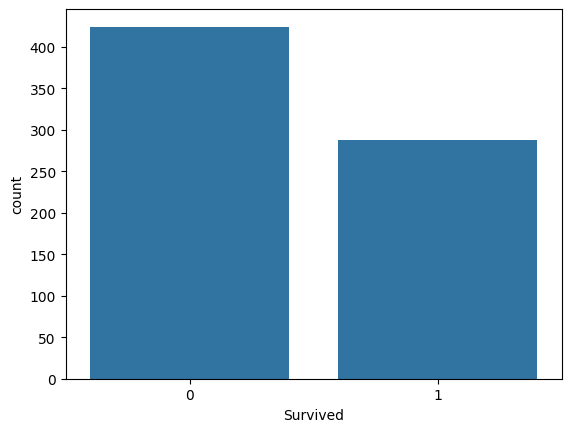

In [10]:
# Take a look at the distribution of the target variable "Survived" to see how many people survived 
# and how many people did not survive.
# 0 represents people who did not survive, and 1 represents people who survived.
sns.countplot(x="Survived", data=titanic_data)

<Axes: xlabel='Pclass', ylabel='Survived'>

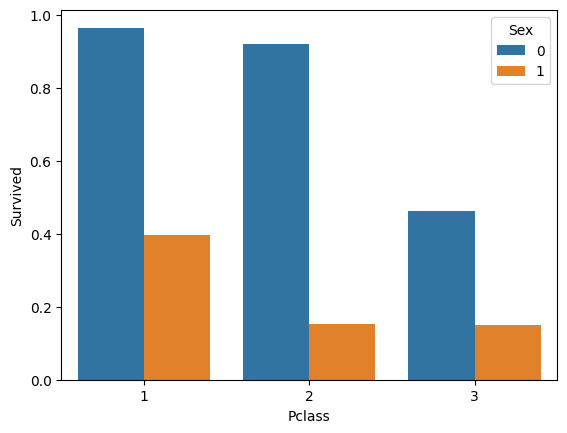

In [11]:
# Take a look at the distribution of the target variable "Survived" based on the "Pclass" 
# and "Sex" columns. Remember that "Pclass" represents the passenger class (1st, 2nd, 
# or 3rd class), and "Sex" is 0 for female and 1 for male. The higher the bar, the higher 
# the survival rate for that group of people.
sns.barplot(x="Pclass", y="Survived", hue="Sex", data=titanic_data, errorbar=None)

<Axes: xlabel='Embarked', ylabel='Survived'>

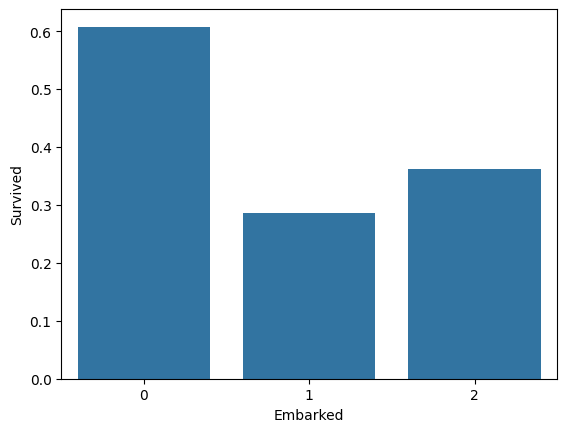

In [12]:
# Take a look at the distribution of the target variable "Survived" based on 
# the "Embarked" column. Remember that "Embarked" is 0 for Cherbourg, 1 for 
# Queenstown, and 2 for Southampton.
sns.barplot(x="Embarked", y="Survived", errorbar=None, data=titanic_data)

<Axes: xlabel='Survived', ylabel='Fare'>

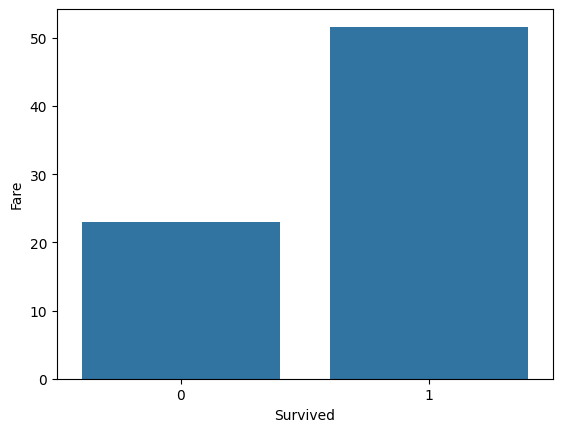

In [13]:
# Take a look at the distribution of the target variable "Survived" based on the average 
# "Fare" column.
sns.barplot(x="Survived", y="Fare", errorbar=None, data=titanic_data)

<Axes: xlabel='Survived', ylabel='Age'>

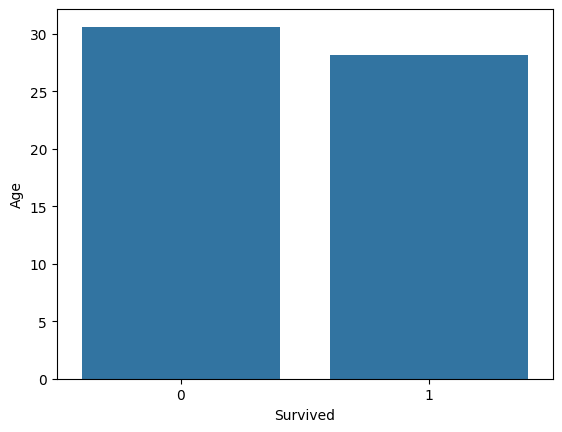

In [14]:
# Now let's take a look at the distribution of the target variable "Survived" based on the average 
# "Age" column. This will allow us to see if there is a relationship between age and survival rate.
sns.barplot(x="Survived", y="Age", errorbar=None, data=titanic_data)

<Axes: xlabel='Parch', ylabel='Survived'>

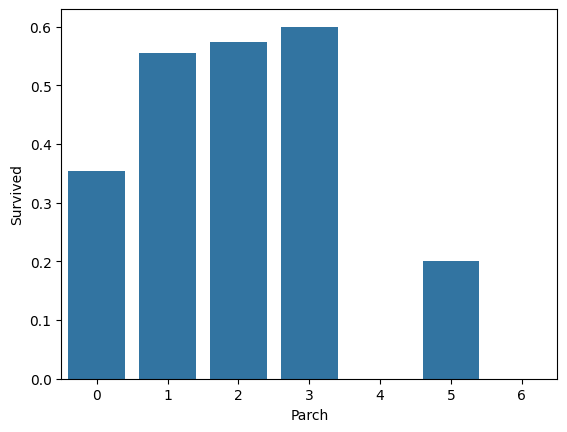

In [15]:
# Finally, let's take a look at the distribution of the target variable "Survived" based on the 
# number of parents/children aboard the Titanic, which is represented by the "Parch" column. 
# This will allow us to see if there is a relationship between having parents/children aboard and 
# survival rate.
sns.barplot(x="Parch", y="Survived", errorbar=None, data=titanic_data)

<Axes: xlabel='SibSp', ylabel='Survived'>

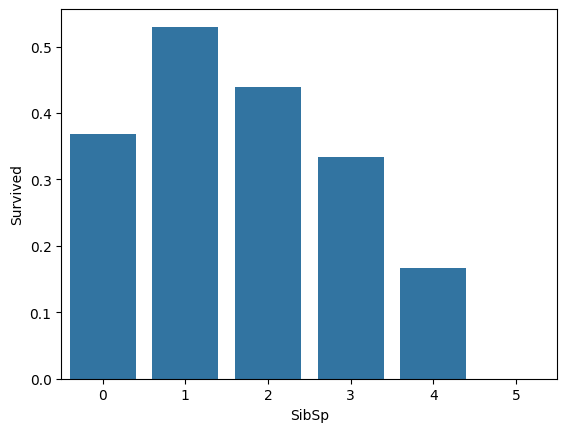

In [16]:
# Finally, let's take a look at the distribution of the target variable "Survived" based on the
# number of siblings/spouses aboard the Titanic, which is represented by the "SibSp" column. 
# This will allow us to see if there is a relationship between having siblings/spouses aboard and
# survival rate.
sns.barplot(x="SibSp", y="Survived", errorbar=None, data=titanic_data)

### First Attempt at a Neural Network

Accuracy: 57.34265734265735 %


/Users/juliebutler/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/juliebutler/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/juliebutler/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/juliebutler/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/juliebutler/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/juliebutler/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


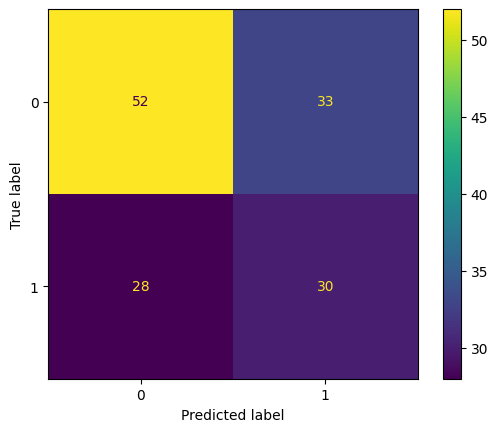

In [17]:
# First we will use the "Age" column as our feature (X) and the "Survived" column as our target variable (y).
# The X data is the input to the neural network, and the y data is the output that we want the neural network
# to predict. In this case, we want the neural network to predict whether a person survived (1) or did not survive (0).
X = titanic_data[["Age"]]
y = titanic_data["Survived"]

# Split the data into training and testing sets. The training set will be used to train the model, and the testing set 
# will be used to evaluate the model's performance. We will use 80% of the data for training and 20% for testing.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Now we will create an instance of the MLPClassifier, which is a type of neural network model. We will specify the
# architecture of the neural network (hidden_layer_sizes), the maximum number of iterations for training (max_iter), 
# and the activation function to use (activation). The hidden_layer_sizes parameter specifies the number of hidden layers 
# and the number of neurons in each hidden layer. In this case, we are using one hidden layer with 10 neurons. We are using 
# the ReLU activation function, which is a common choice for hidden layers in neural networks. Finally, we will train the network
# using 300 iterations.
mlp = MLPClassifier(hidden_layer_sizes=(10), max_iter=300, activation="relu")

# Train the model using both the X_train and y_train data. The neural network will learn the relationship between the input data 
# (X_train) and the output data (y_train) during this step.
mlp.fit(X_train, y_train)

# After training the model, we can use it to make predictions on the testing data (X_test). The model will output predicted values 
# for the target variable (y_pred) based on the input data (X_test).
y_pred = mlp.predict(X_test)

# Print the accuracy of the model, which is the percentage of correct predictions out of all predictions made. The accuracy_score function
# compares the true values (y_test) with the predicted values (y_pred) and calculates the accuracy. We multiply by 100 to convert it to a 
# percentage and add a "%" sign for readability.
print("Accuracy:", accuracy_score(y_test, y_pred)*100, "%")


ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

### Attempts to Improve Accuracy

#### Feature Engineering and Pre-Processing the Data Set
Instead of using a single randomly selected feature as the input to the neural network, we can use multiple features as input to the neural network. This will allow the model to learn more complex relationships between the input data and the target variable, which can potentially improve the model's performance. In this case, we will use features which seem to be related to the "Survived" column based on our previous visualizations: "Pclass", "Sex", "Fare", and "SibSp". The output of the neural network is still the "Survived" column, which is our target variable (y). 

We will also standardize the input data (X) using `StandardScaler`, which could potentially improve performance. Standard scaler will transform the different columns in X to make sure they are all the same size number. Some times a machine learning algorithm can view large numbers as more important than small numbers, even if that is not neccessarily true. This also helps to make sure the network can learn every training iteration instead of getting stuck. This process is called *pre-processing* the data.

accuracy_score: 76.22377622377621 %


/Users/juliebutler/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/juliebutler/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/juliebutler/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/juliebutler/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/juliebutler/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/juliebutler/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


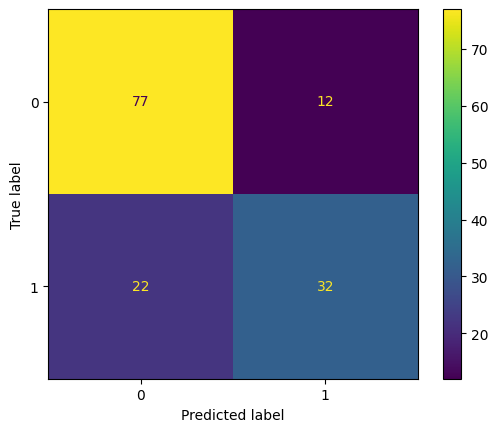

In [22]:
# Set up the new input data (X) and target variable (y) for the neural network.
X = titanic_data[["Pclass","Sex","Fare", "SibSp"]]
y = titanic_data["Survived"]

# Standardize the input data using StandardScaler to make sure that the features are on the same scale. 
Z = StandardScaler().fit_transform(X)

# Split the scaled input data and output data into training and testing sets, using the same 80% for 
# training and 20% for testing as before.
X_train, X_test, y_train, y_test = train_test_split(Z, y, test_size=0.2)

# Create a new instance of the MLPClassifier with the same architecture and parameters as before, 
# and train it on the new input data (Z) and target variable (y). Generate predictions using the new model.
mlp_2 = MLPClassifier(hidden_layer_sizes=(10), max_iter=300, activation="relu")
mlp_2.fit(X_train, y_train)
y_pred = mlp_2.predict(X_test)

# Print the accuracy of the new model and display the confusion matrix to evaluate its performance.
print("accuracy_score:", 100*accuracy_score(y_test, y_pred), "%")
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

#### Make the Network Deeper

While feature engineering and pre-processing our data improved the accuracy, we may still be able to increase it by changing the neural network. The first thing we can do is increase the number of layers in our neural network. The idea behind having multiple layers, as opposed to one large layer, is that each layer will further refine the data and find new patterns. Instead of the single layer of 10 neurons we had in the previous networks, let's change that to two layers, each with 5 neurons. Therefore we have the same number of neurons as the previous network, but in a different arrangement.

0.7832167832167832


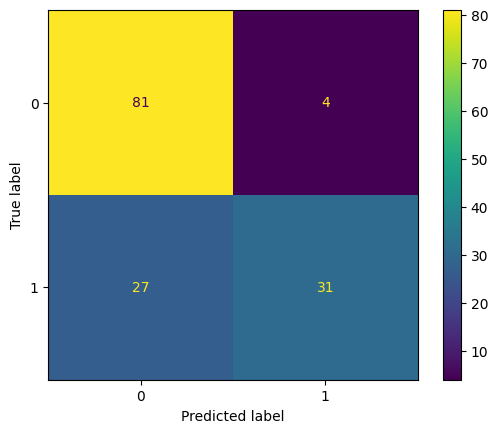

In [23]:
X = titanic_data[["Pclass","Sex","Fare", "SibSp"]]
y = titanic_data["Survived"]

Z = StandardScaler().fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(Z, y, test_size=0.2)

mlp2 = MLPClassifier(hidden_layer_sizes=(5, 5), max_iter=300, activation="relu")
mlp2.fit(X_train, y_train)
y_pred = mlp2.predict(X_test)

print(accuracy_score(y_test, y_pred))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

### Or Make the Network Wider

/Users/juliebutler/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/juliebutler/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/juliebutler/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


0.7972027972027972


/Users/juliebutler/Library/Python/3.9/lib/python/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/juliebutler/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/juliebutler/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/juliebutler/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


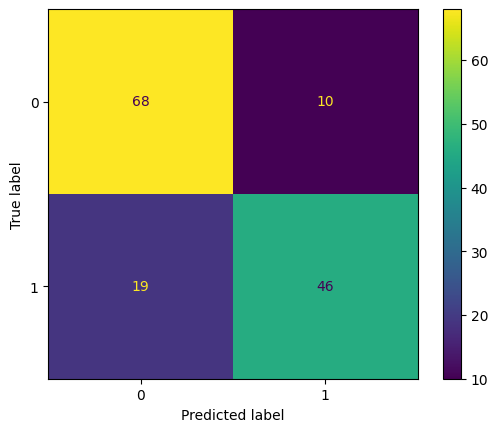

In [ ]:
X = titanic_data[["Pclass","Sex","Fare", "SibSp"]]
y = titanic_data["Survived"]

Z = StandardScaler().fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(Z, y, test_size=0.2)

mlp2 = MLPClassifier(hidden_layer_sizes=(25, 10), max_iter=300, activation="relu")
mlp2.fit(X_train, y_train)
y_pred = mlp2.predict(X_test)

print(accuracy_score(y_test, y_pred))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

#### Change the Activation Function and Iterations

/Users/juliebutler/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/juliebutler/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/juliebutler/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


0.7202797202797203


/Users/juliebutler/Library/Python/3.9/lib/python/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (450) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/juliebutler/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/juliebutler/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/juliebutler/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


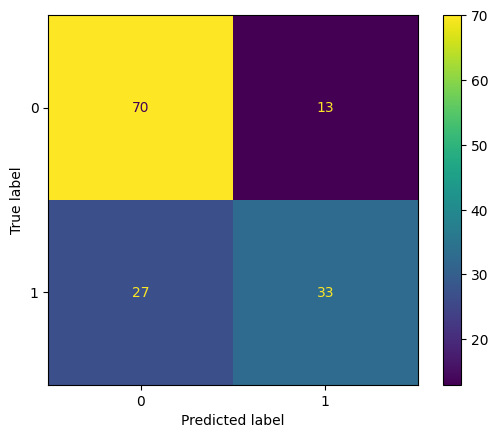

In [ ]:
X = titanic_data[["Pclass","Sex","Fare", "SibSp"]]
y = titanic_data["Survived"]

Z = StandardScaler().fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(Z, y, test_size=0.2)

mlp2 = MLPClassifier(hidden_layer_sizes=(25, 25), max_iter=450, activation="tanh")
mlp2.fit(X_train, y_train)
y_pred = mlp2.predict(X_test)

print(accuracy_score(y_test, y_pred))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

## Conclusion and Future Directions
